<a href="https://colab.research.google.com/github/Aryan-Rajak/thiranex-3/blob/main/thiranex_3_arya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('retail_sales_dataset (1).csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['DayName'] = df['Date'].dt.day_name()

# Numerical correlations
num_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount', 'Month', 'DayOfWeek']
corr = df[num_cols].corr()
print("Correlation Matrix:")
print(corr)

# Check distribution of Price per Unit and Quantity
print("\nUnique Price per Unit counts:")
print(df['Price per Unit'].value_counts().sort_index())

print("\nUnique Quantity counts:")
print(df['Quantity'].value_counts().sort_index())

print("\nMean Spend by Day of Week:")
print(df.groupby('DayName')['Total Amount'].agg(['count', 'sum', 'mean']).loc[
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
])

print("\nCategory Price & Quantity statistics:")
print(df.groupby('Product Category')[['Price per Unit', 'Quantity', 'Total Amount']].describe())

Correlation Matrix:
                     Age  Quantity  Price per Unit  Total Amount     Month  \
Age             1.000000 -0.023737       -0.038423     -0.060568 -0.000640   
Quantity       -0.023737  1.000000        0.017501      0.373707 -0.021803   
Price per Unit -0.038423  0.017501        1.000000      0.851925 -0.008161   
Total Amount   -0.060568  0.373707        0.851925      1.000000 -0.005197   
Month          -0.000640 -0.021803       -0.008161     -0.005197  1.000000   
DayOfWeek       0.024743 -0.040846        0.041272      0.009262 -0.008455   

                DayOfWeek  
Age              0.024743  
Quantity        -0.040846  
Price per Unit   0.041272  
Total Amount     0.009262  
Month           -0.008455  
DayOfWeek        1.000000  

Unique Price per Unit counts:
Price per Unit
25     210
30     183
50     211
300    197
500    199
Name: count, dtype: int64

Unique Quantity counts:
Quantity
1    253
2    243
3    241
4    263
Name: count, dtype: int64

Mean Spend by

/tmp/ipykernel_3205/1845218885.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Product Category', y='Total Amount', palette='Pastel1', ax=axes[0, 1], showmeans=True,
/tmp/ipykernel_3205/1845218885.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_spend, x='DayName', y='sum', ax=axes[1, 0], palette='crest')


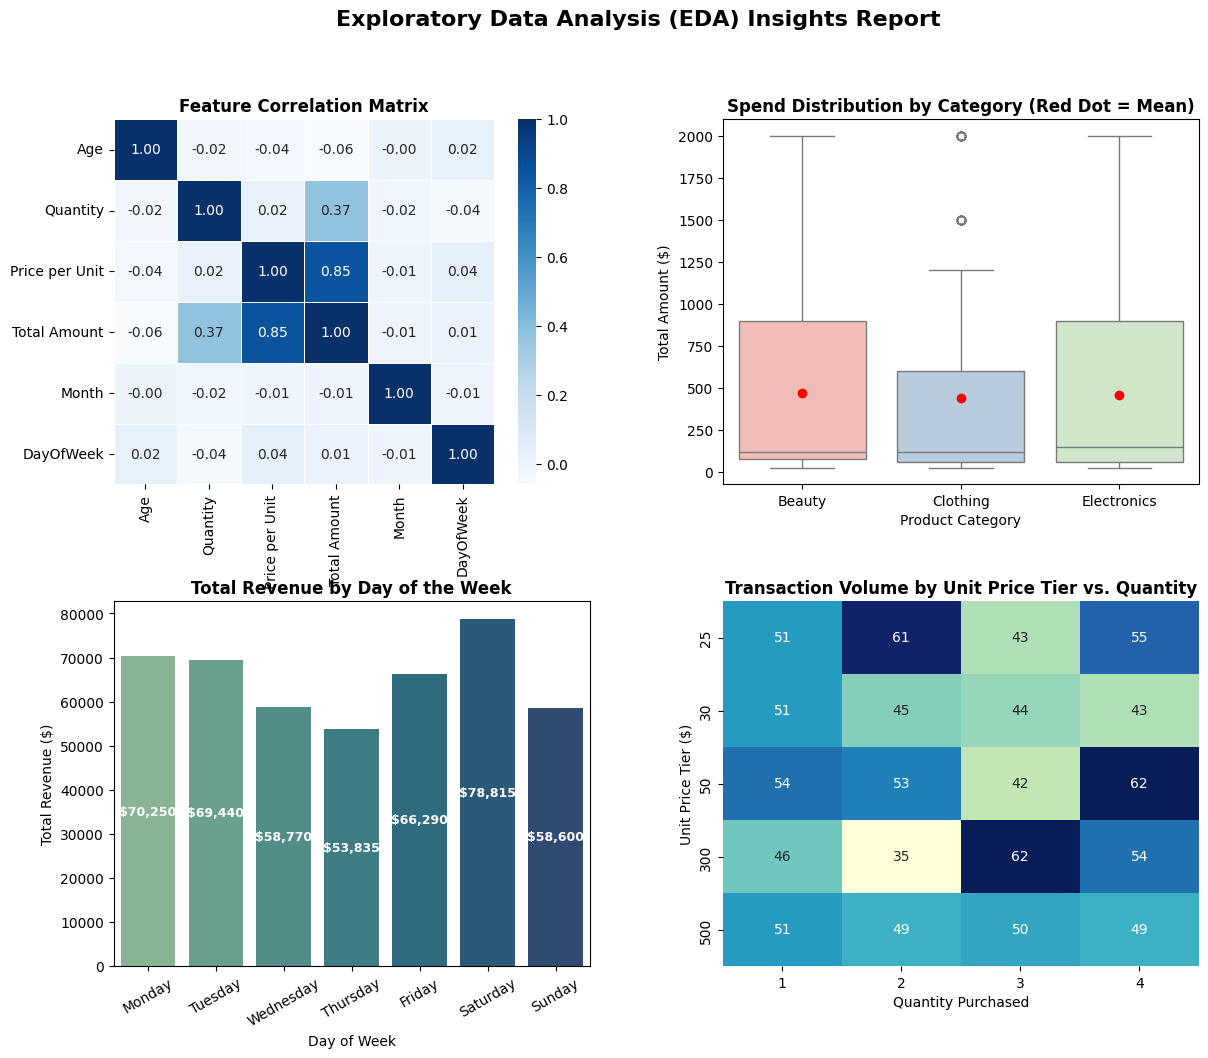

In [2]:
# Create EDA visualization figures
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
plt.subplots_adjust(hspace=0.32, wspace=0.28)

# 1. Correlation Heatmap
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', cbar=True, ax=axes[0, 0], linewidths=0.5)
axes[0, 0].set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')

# 2. Total Spend Distribution by Category (Boxplot with strip)
sns.boxplot(data=df, x='Product Category', y='Total Amount', palette='Pastel1', ax=axes[0, 1], showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"red", "markersize":"6"})
axes[0, 1].set_title('Spend Distribution by Category (Red Dot = Mean)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Total Amount ($)')
axes[0, 1].set_xlabel('Product Category')

# 3. Spend by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_spend = df.groupby('DayName')['Total Amount'].agg(['sum', 'mean']).loc[day_order].reset_index()

sns.barplot(data=day_spend, x='DayName', y='sum', ax=axes[1, 0], palette='crest')
axes[1, 0].set_title('Total Revenue by Day of the Week', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Total Revenue ($)')
axes[1, 0].tick_params(axis='x', rotation=30)
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"${p.get_height():,.0f}",
                        (p.get_x() + p.get_width() / 2., p.get_height() * 0.5),
                        ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# 4. Discrete Price Tier & Quantity Interaction
tier_qty = pd.crosstab(df['Price per Unit'], df['Quantity'])
sns.heatmap(tier_qty, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1, 1], cbar=False)
axes[1, 1].set_title('Transaction Volume by Unit Price Tier vs. Quantity', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Quantity Purchased')
axes[1, 1].set_ylabel('Unit Price Tier ($)')

plt.suptitle('Exploratory Data Analysis (EDA) Insights Report', fontsize=16, fontweight='bold', y=0.98)
plt.savefig('eda_insights_report.png', dpi=300, bbox_inches='tight')
plt.show()